# Fake News Detection using Machine Learning

This project aims to classify news articles as REAL or FAKE using Natural Language Processing (NLP) and machine learning techniques.

### Importing Required Libraries

We import essential libraries for data handling, preprocessing, model building, and evaluation.

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot

### Loading the Dataset

The dataset contains news articles with features such as Unnamed: 0, title, text, and label (REAL/FAKE).  
We load the dataset into a pandas DataFrame and inspect its structure.

In [2]:
df = pd.read_csv("news.csv")
df.sample(5)

,Unnamed: 0,title,text,label
3893,4139,Six cities submit bids to host 2016 Democratic...,(CNN) - Meet the super six vying for the 2016 ...,REAL
2956,7059,Report Exposes Inner Workings of Facebook and ...,posted by Eddie Censorship by Facebook has bec...,FAKE
4889,8526,CETA Is Step towards a Corporate Land Called E...,3 Shares\n2 0 0 1\nThe signing of the Comprehe...,FAKE
3045,647,Bernie Sanders is expected to endorse Hillary ...,It's amazing to go back and watch Bernie Sande...,REAL
1008,3506,"Thanks to Obama, the terrorist cancer is growing",We still do not know who or what is responsibl...,REAL


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  6335 non-null   int64
 1   title       6335 non-null   str  
 2   text        6335 non-null   str  
 3   label       6335 non-null   str  
dtypes: int64(1), str(3)
memory usage: 198.1 KB


### Data Preprocessing

In this step:
- Removed unnecessary columns (e.g., Unnamed column)
- Combined title and text into a single column called **content**
- Reduced dataset to only relevant columns: content and label

This helps simplify the dataset for NLP processing.

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df = df.drop(['Unnamed: 0'], axis=1)
df['content'] = df['title'] + " " + df['text']

In [6]:
df = df[['content', 'label']]
df.sample(2)

,content,label
4143,The awful truth about climate change no one wa...,REAL
3878,Donald Trump in the hunt for a VP: Who's got t...,REAL


In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove punctuation/numbers
    return text

df['content'] = df['content'].apply(clean_text)
df.sample(5)

,content,label
2396,how to open your chakras as explained by a ch...,FAKE
6131,state dept accused of stiffarming intel watchd...,REAL
6101,should nbc have let donald trump host saturday...,REAL
2877,donald trumps success reveals a frightening we...,REAL
5096,iran nuclear agreement is a better deal possib...,REAL


<Axes: xlabel='label'>

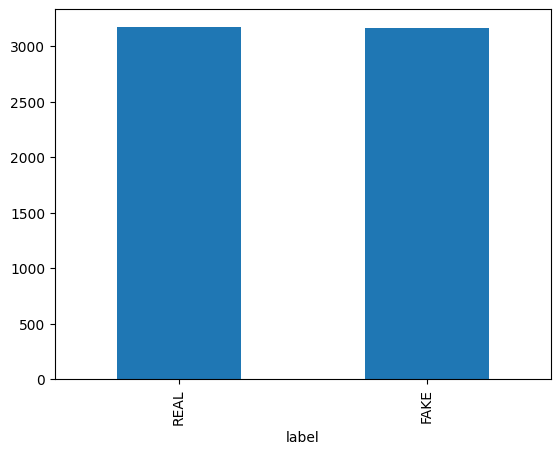

In [8]:
df['label'].value_counts().plot(kind = 'bar')

### Train-Test Split

The dataset is split into training and testing sets:
- Training set: used to train the model
- Testing set: used to evaluate performance

We use an 80-20 split.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    df['content'], df['label'], test_size=0.2, random_state=7
)

### Feature Extraction using TF-IDF

Text data is converted into numerical form using TF-IDF (Term Frequency - Inverse Document Frequency).

This helps represent the importance of words in each document relative to the entire dataset.

In [11]:
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7, ngram_range=(1,2))

tfidf_train = tfidf.fit_transform(x_train)
tfidf_test = tfidf.transform(x_test)

### Model Training using Support Vector Machine (SVM)

We use LinearSVC, a type of Support Vector Machine optimized for text classification.

It works well with high-dimensional sparse data like TF-IDF vectors.

In [12]:
model = LinearSVC(C=0.5)
model.fit(tfidf_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.5
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [13]:
y_pred = model.predict(tfidf_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9313338595106551


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        FAKE       0.94      0.92      0.93       638
        REAL       0.92      0.94      0.93       629

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



### Prediction on New Data

A custom function is created to:
- Clean input text
- Transform it using the trained TF-IDF vectorizer
- Predict whether the news is REAL or FAKE

This simulates real-world usage of the model.

In [17]:
def predict_news(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)  

    vec = tfidf.transform([text])   
    result = model.predict(vec)

    return result[0]

In [18]:
predict_news(""" Israel says troops fighting Hezbollah surrounded key Lebanon town

The Israeli military said on Monday (April 13, 2026) its troops had completely surrounded a key town in southern Lebanon after killing more than 100 Hezbollah fighters there over the past week.

The announcement marks a significant advance in Israel’s ongoing invasion of southern Lebanon.

“The forces of the 98th Division have completed the encirclement of the town of Bint Jbeil and have begun an assault on it,” the military’s Arabic-language spokesman Colonel Avichay Adraee said on X.

Over the past week, Israeli forces have killed more than 100 Hezbollah fighters in and around the town in “face-to-face” clashes and with air strikes, he said.

Prime Minister Benjamin Netanyahu said at a cabinet meeting that since Sunday the fighting in southern Lebanon had been “concentrated” in Bint Jbeil.

“The fighting continues. It has not stopped — it is ongoing all the time. Yesterday and today it has been concentrated in Bint Jbeil,” he said, according to a video statement released by his office on Monday (April 13, 2026).

Mr. Netanyahu said that Israeli troops were pushing Hezbollah fighters away from the border.

“We are talking about a solid security belt, deeper than before, one that prevents the danger of infiltration and pushes back the anti-tank threat,” he said.

“They are also dealing with the terror villages that were right up against us — every terror position, and there were many, has simply been flattened.”

The Iran-backed Hezbollah said it has been engaged for days in clashes with Israeli forces in Bint Jbeil. -- AFP""")

'REAL'

In [19]:
predict_news("""Salman Khan has been romantically linked to many celebrities in the past and for many years, fans kept hoping that Salman would announce his wedding sooner or later. A few years ago, at the Star Screen Awards, the Dabangg actor was once again questioned about his marriage by Shah Rukh Khan, and Salman’s response shocked everyone present at the event.

When Shah Rukh Khan inquired about his marriage plans, Salman casually replied, “Secret ye hai ki meri shaadi ho chuki hai (The secret is that I have already gotten married).” This left Shah Rukh and other stars present at the award show, including Alia Bhatt, Zareen Khan, Daisy Shah, Rekha and others, in shock. SRK asked, “What? Teri shaadi ho chuke hai? (You are already married?).” Salman continued, “Those who keep bothering me, asking about my marriage plans. I am fed up of telling this lie – 18 November, 18 November.”

Shah Rukh further inquired, “Where did you get married?” Salman said, “We have been married for sometime now. I have hid this fact from the world but it came out today in front of you and I might tell the whole world now.”
Also read | Angry Young Men trailer: Salman Khan recalls how Salim-Javed destroyed critics with work, Shabana Azmi says success made them arrogant

When Shah Rukh insisted on knowing where did Salman got married, he said with a straight face, “Sapno mein (In my dreams).” Salman’s response had the whole audience erupt in laughter. Shah Rukh, while laughing, asked, “Whom did you marry in your dreams?” The Tiger Zinda Hai actor explained, “Whenever the girl enters my dream, I feel nervous and I wake up. So, I have never seen the girl.” This further had the audience and SRK in splits who then joked about how many girls want to marry Salman, but even in his dreams, he gets nervous at the thought of marriage.

In an interview with Aap Ki Adalat, Salman had expressed his wish to become a father, stating that while he isn’t focused on marriage, he does want to have children but is hindered by Indian law. He said, “That’s what I was trying to do. But, that law may have changed, so let’s see. I am very fond of children. But when kids come then their mother also comes. A mother is good for them but we have a lot of mothers at home. We have the whole district, the whole village. They will take care of them. But my kid’s real mother will also be my wife.”""")

'FAKE'

In [ ]:
# Take random 20 samples
sample_df = df.sample(n=20, random_state=42)

# Save to new file
sample_df.to_csv("sample_dataset.csv", index=False)
sample_df.head(5)